In [1]:
import numpy as np
import matplotlib.pyplot as plt

(0.0, 50.0)

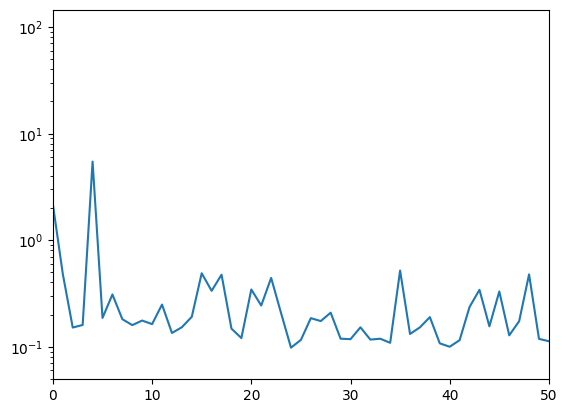

In [ ]:
t = np.genfromtxt('checkpoints/losses.txt')

plt.plot(t)
plt.yscale('log')
plt.xlim(0, 50)
pl

(0.05, 1400.0)

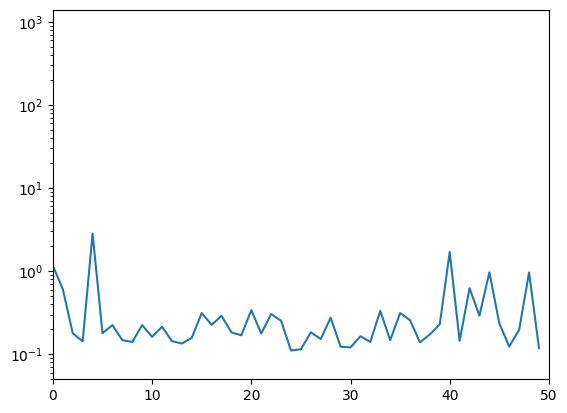

In [10]:
t = np.genfromtxt('checkpoints/losses.txt')

plt.plot(t)
plt.yscale('log')
plt.xlim(0, 50)
plt.ylim(5e-2, 1.4e3)

In [11]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import jax
import jax.numpy as jnp

from train import F_true

# F_true takes a single point x = (t, drho, dp, du) and returns the 3-vector
# face flux (mass, momentum, energy). F(t) = t * f(u*(0)) so we use t=1 to
# read off the instantaneous flux.
F_batch = jax.jit(jax.vmap(F_true))

N = 80
# Pull endpoints slightly inside the singular boundaries (vacuum at |drho|=|dp|=1
# and du=1) so the heatmaps stay finite.
drho_grid = jnp.linspace(-0.99, 0.99, N)
dp_grid   = jnp.linspace(-0.99, 0.99, N)
du_grid   = jnp.linspace(-1.99, 0.95, N)

t_eval = 1.0


def eval_slice(A, B, C):
    pts = jnp.stack([jnp.full_like(A, t_eval), A, B, C], axis=-1).reshape(-1, 4)
    return F_batch(pts).reshape(A.shape + (3,))


# Three 2-D slices through the origin of the held-out delta.
DRHO, DP = jnp.meshgrid(drho_grid, dp_grid, indexing="ij")
F_drho_dp = eval_slice(DRHO, DP, jnp.zeros_like(DRHO))

DRHO, DU = jnp.meshgrid(drho_grid, du_grid, indexing="ij")
F_drho_du = eval_slice(DRHO, jnp.zeros_like(DRHO), DU)

DP, DU = jnp.meshgrid(dp_grid, du_grid, indexing="ij")
F_dp_du = eval_slice(jnp.zeros_like(DP), DP, DU)

print("flux shapes:", F_drho_dp.shape, F_drho_du.shape, F_dp_du.shape)

flux shapes: (80, 80, 3) (80, 80, 3) (80, 80, 3)


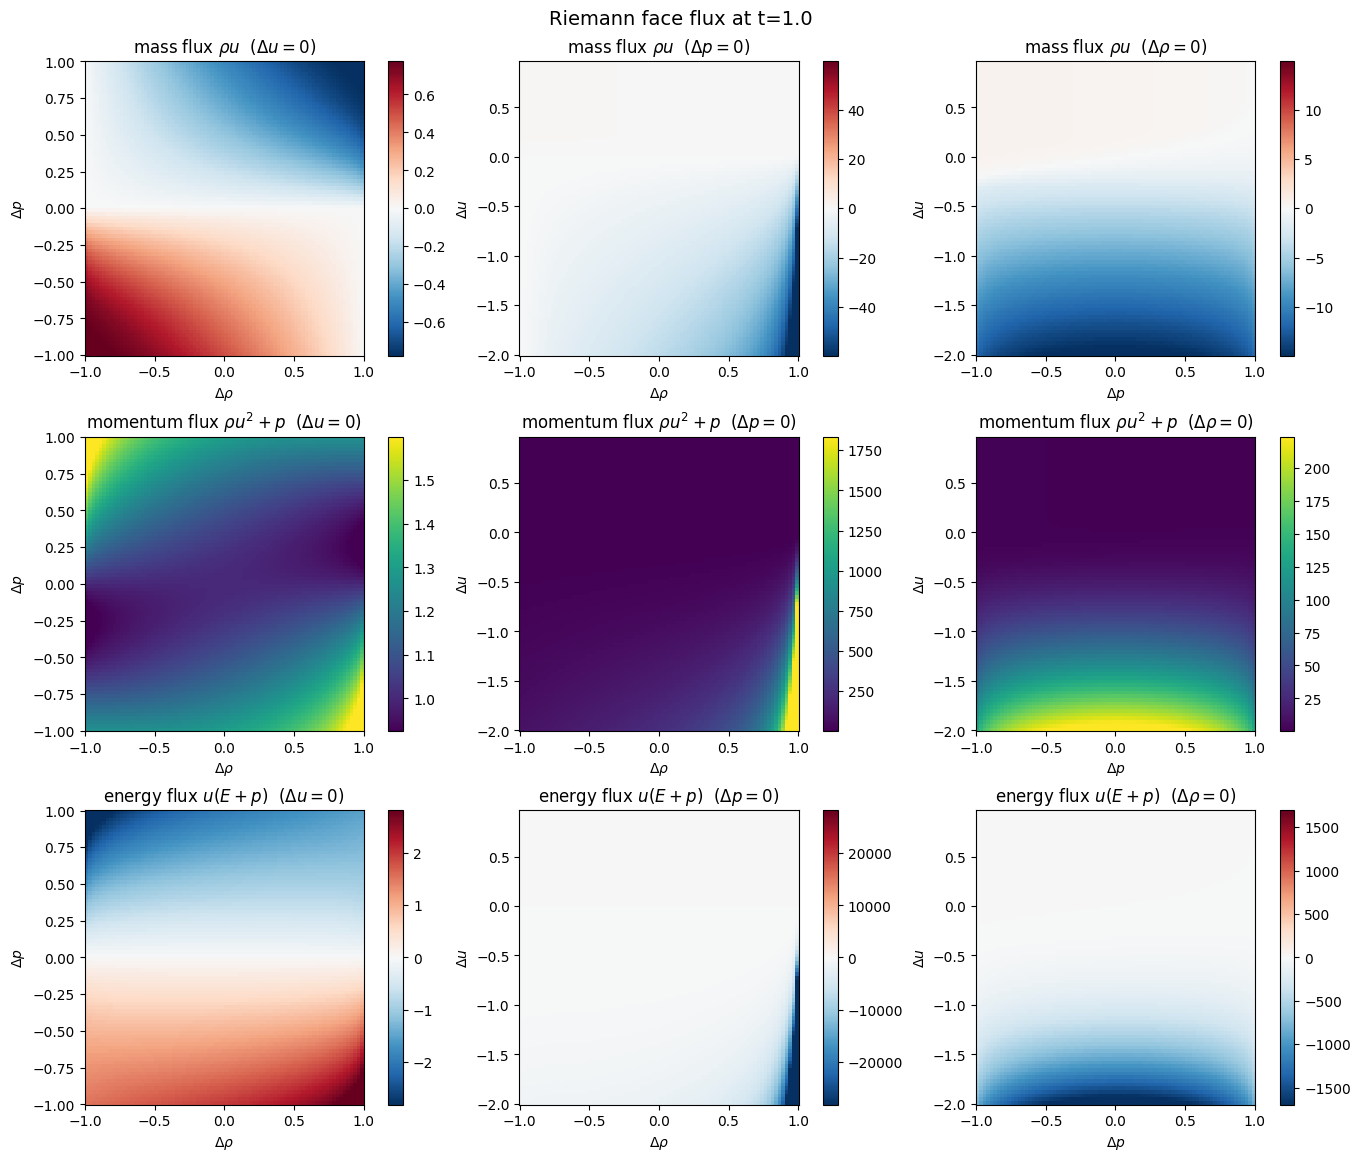

In [12]:
from matplotlib.colors import TwoSlopeNorm

component_names = [
    r"mass flux $\rho u$",
    r"momentum flux $\rho u^2 + p$",
    r"energy flux $u(E + p)$",
]
slices = [
    ("$\\Delta\\rho$", "$\\Delta p$", drho_grid, dp_grid, F_drho_dp, "$\\Delta u = 0$"),
    ("$\\Delta\\rho$", "$\\Delta u$", drho_grid, du_grid, F_drho_du, "$\\Delta p = 0$"),
    ("$\\Delta p$",   "$\\Delta u$", dp_grid,   du_grid, F_dp_du,   "$\\Delta\\rho = 0$"),
]

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.5), constrained_layout=True)
for i, name in enumerate(component_names):
    for j, (xn, yn, xg, yg, F, fixed) in enumerate(slices):
        ax = axes[i, j]
        z = np.asarray(F[..., i]).T  # transpose so first arg is on x-axis
        finite = z[np.isfinite(z)]
        if i == 1:  # momentum flux is positive (rho*u^2 + p > 0), use a sequential cmap
            vmin = np.percentile(finite, 1)
            vmax = np.percentile(finite, 99)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
            )
        else:  # mass / energy fluxes change sign, center the colormap at 0
            vmax = np.percentile(np.abs(finite), 99)
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
            im = ax.pcolormesh(
                np.asarray(xg), np.asarray(yg), z,
                cmap="RdBu_r", norm=norm, shading="auto",
            )
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(xn)
        ax.set_ylabel(yn)
        ax.set_title(f"{name}  ({fixed})")

fig.suptitle(f"Riemann face flux at t={t_eval}", fontsize=14)
plt.show()